# 05. Baseline Models - Automobile Loan Default Prediction


## 1. Setup

In [1]:
import os
import sys

project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from src.config import RANDOM_STATE, TARGET
from src.data.data_cleaning import clean_and_split
from src.evaluation.metrics import evaluate_model

train_df, test_df = clean_and_split()
X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Default rate (train):", round(y_train.mean(), 4))
print("Default rate (test):", round(y_test.mean(), 4))

X_train shape: (95372, 40)
X_test shape: (23844, 40)
Default rate (train): 0.081
Default rate (test): 0.081


## 2. Random Forest

Bagging ensemble. Note this is a *second*, independent Random Forest - a different one already runs inside the pipeline's `ImportanceFeatureSelector` step (feature selection), this one is the actual candidate model, fit and scored on the selected/scaled features that step produces.

In [3]:
from src.models.random_forest import build_random_forest_pipeline

rf_pipeline = build_random_forest_pipeline()

rf_results = evaluate_model(rf_pipeline, X_train, y_train, model_name="random_forest", cv=5)

for key, value in rf_results.items():
    print(f"{key}: {value}")

model_name: random_forest
cv_folds: 5
threshold: 0.5
roc_auc_mean: 0.7740530162105269
roc_auc_std: 0.00399387962965928
pr_auc_mean: 0.3575537792965477
pr_auc_std: 0.00932055501149178
recall_mean: 0.16338598521052367
precision_mean: 0.6320702646114715
f1_mean: 0.25954910625331074
confusion_matrix: [[86910, 738], [6462, 1262]]
fit_seconds: 45.67


In [4]:
rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline[:-1].transform(X_train).columns
rf_importances = pd.Series(
    rf_pipeline.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

print("Top 10 Random Forest feature importances:")
print(rf_importances.head(10))

Top 10 Random Forest feature importances:
score_mean           0.087051
score_min            0.070747
Score_Source_2       0.056280
Score_Source_3       0.049631
Age_Years            0.046665
Employed_Days        0.044843
Credit_Loan_Ratio    0.044656
ID_Days              0.043860
Registration_Days    0.042627
Credit_Amount        0.040610
dtype: float64


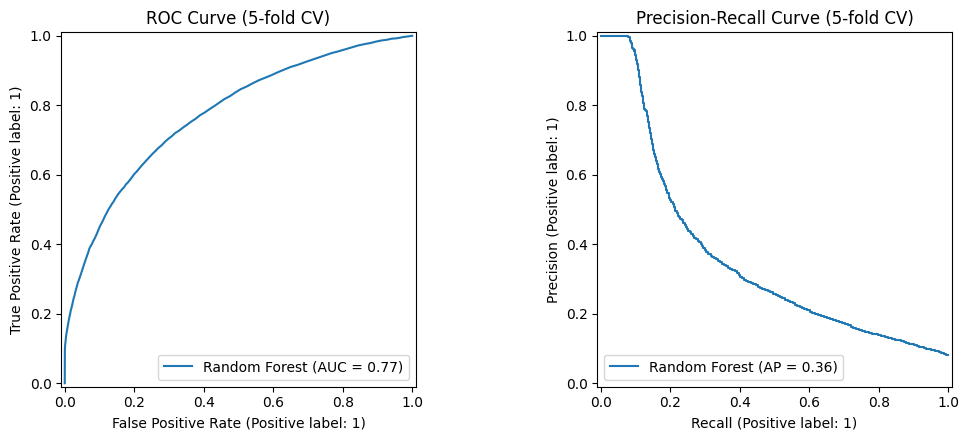

In [5]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_cv_proba = cross_val_predict(rf_pipeline, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_train, rf_cv_proba, ax=axes[0], name="Random Forest")
axes[0].set_title("ROC Curve (5-fold CV)")
PrecisionRecallDisplay.from_predictions(y_train, rf_cv_proba, ax=axes[1], name="Random Forest")
axes[1].set_title("Precision-Recall Curve (5-fold CV)")
plt.tight_layout()

figures_dir = "experiments/figures" if os.path.exists("experiments/figures") else "../experiments/figures"
plt.savefig(os.path.join(figures_dir, "05_random_forest_roc_pr.png"), dpi=100, bbox_inches="tight")
plt.show()

In [6]:
from src.evaluation.metrics import log_result_to_csv

results_dir = "experiments/results" if os.path.exists("experiments/results") else "../experiments/results"
experiments_path = os.path.join(results_dir, "experiments.csv")

log_result_to_csv(rf_results, experiments_path)
print(f"Logged to {experiments_path}")
pd.read_csv(experiments_path)

Logged to ../experiments/results\experiments.csv


,model_name,cv_folds,threshold,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,precision_mean,f1_mean,fit_seconds,tn,fp,fn,tp
0,random_forest,5,0.5,0.774053,0.003994,0.357554,0.009321,0.163386,0.63207,0.259549,45.67,86910,738,6462,1262


**Finding:** Random Forest 5-fold CV - ROC-AUC 0.774, PR-AUC 0.358 (both stronger than the Logistic Regression baseline). At the default 0.5 threshold, recall is only 0.163 - `class_weight="balanced"` alone doesn't push RF's predicted probabilities the way it does for Logistic Regression, so most actual defaulters are currently missed. Threshold tuning (Stage 7) will matter more for this model than for the linear baseline.

**Decision:** ported to `src/models/random_forest.py` as `build_random_forest_pipeline()`.

## 3. Gaussian Naive Bayes

Fast probabilistic baseline. Correct NB variant for our data - it assumes real-valued, normally-distributed features per class, which fits our standard-scaled continuous features (unlike Multinomial NB, which needs non-negative counts). Expected to underperform the ensembles: it assumes features are independent given the class, which breaks for correlated features like `score_mean` vs. `Score_Source_1/2/3`, or `credit_to_income` vs. `Credit_Amount`.

In [7]:
from src.models.gaussian_naive_bayes import build_gaussian_naive_bayes_pipeline

nb_pipeline = build_gaussian_naive_bayes_pipeline()

nb_results = evaluate_model(nb_pipeline, X_train, y_train, model_name="gaussian_naive_bayes", cv=5)

for key, value in nb_results.items():
    print(f"{key}: {value}")

model_name: gaussian_naive_bayes
cv_folds: 5
threshold: 0.5
roc_auc_mean: 0.6968148761053206
roc_auc_std: 0.0037030615699304554
pr_auc_mean: 0.17624826703380017
pr_auc_std: 0.008833369769757678
recall_mean: 0.47902744940221675
precision_mean: 0.16953155835638128
f1_mean: 0.25039393707133817
confusion_matrix: [[69518, 18130], [4024, 3700]]
fit_seconds: 17.15


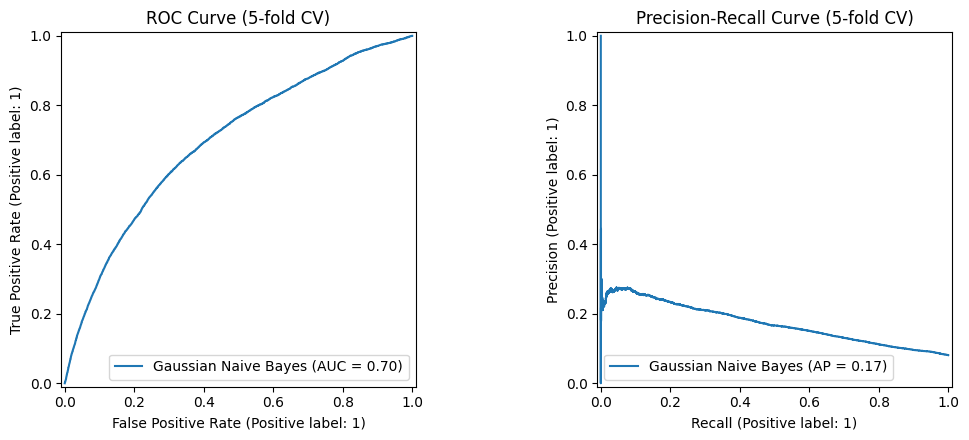

In [8]:
nb_cv_proba = cross_val_predict(nb_pipeline, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_train, nb_cv_proba, ax=axes[0], name="Gaussian Naive Bayes")
axes[0].set_title("ROC Curve (5-fold CV)")
PrecisionRecallDisplay.from_predictions(y_train, nb_cv_proba, ax=axes[1], name="Gaussian Naive Bayes")
axes[1].set_title("Precision-Recall Curve (5-fold CV)")
plt.tight_layout()

plt.savefig(os.path.join(figures_dir, "05_gaussian_nb_roc_pr.png"), dpi=100, bbox_inches="tight")
plt.show()

In [9]:
log_result_to_csv(nb_results, experiments_path)
print(f"Logged to {experiments_path}")
pd.read_csv(experiments_path)

Logged to ../experiments/results\experiments.csv


,model_name,cv_folds,threshold,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,precision_mean,f1_mean,fit_seconds,tn,fp,fn,tp
0,random_forest,5,0.5,0.774053,0.003994,0.357554,0.009321,0.163386,0.632070,0.259549,45.67,86910,738,6462,1262
1,gaussian_naive_bayes,5,0.5,0.696815,0.003703,0.176248,0.008833,0.479027,0.169532,0.250394,17.15,69518,18130,4024,3700


**Finding:** Gaussian Naive Bayes 5-fold CV - ROC-AUC 0.697, PR-AUC 0.176, weaker than Random Forest (0.774/0.358) as expected from the broken independence assumption. Notably, recall is higher than Random Forest's at the default threshold (0.479 vs. 0.163) - NB's probability estimates aren't as conservative near the decision boundary, at the cost of much lower precision (0.170 vs. 0.632).

**Decision:** ported to `src/models/gaussian_naive_bayes.py` as `build_gaussian_naive_bayes_pipeline()`.